In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [36]:
#"confounder = already high earing drivers
#I put  30 dollars as treatment effect  that my feature gonna increase hypothetically 
#ab test failed cz of confounders as there were more increase instead of treatment as the reason xan be snything that confounders increased


In [37]:
np.random .seed(40)
num_drivers = 5000
base_earning = np.random .normal( loc = 600, scale =100, size = num_drivers)
base_earning = np.clip(base_earning, 100, 1200)
z_score = (base_earning - 600) / 100
opt_in_probabilities = 1 / (1 + np.exp(-3 * z_score))
used_map = np.random.binomial(n=1, p=opt_in_probabilities)
random_noise = np.random.normal(loc=0, scale=20, size=num_drivers)
#treatment 30 dollars
post_pay = base_earning  + (30 * used_map) + random_noise
uber_df= pd.DataFrame({
    'drivers_id': np.arange(1, num_drivers + 1),
    'baseline_earning': np.round(base_earning, 2),
    "use_serge_heat_map": used_map,
    'post_earning': np.round( post_pay, 2)
})

In [4]:
uber_df.head()

,drivers_id,baseline_earning,use_serge_heat_map,post_earning
0,1,539.25,0,511.85
1,2,587.39,0,579.09
2,3,531.54,0,538.88
3,4,692.87,1,717.91
4,5,415.56,0,374.28


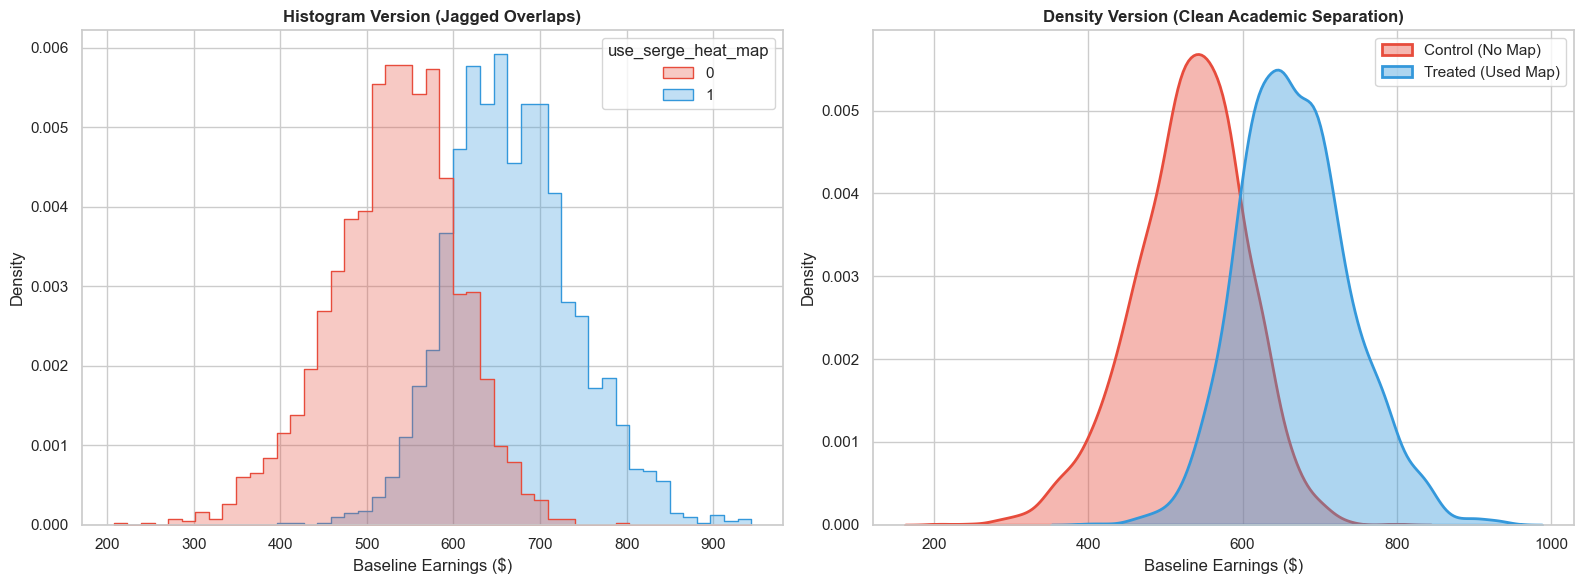

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for a clean academic presentation
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Overlapping Histograms (The blocky view)
sns.histplot(data=uber_df, x='baseline_earning', hue='use_serge_heat_map', 
             element='step', stat='density', common_norm=False, alpha=0.3, ax=axes[0], palette=['#e74c3c', '#3498db'])
axes[0].set_title('Histogram Version (Jagged Overlaps)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Baseline Earnings ($)')

# Right Plot: Continuous KDE Density Curves (The polished econometrics view)
sns.kdeplot(data=uber_df[uber_df['use_serge_heat_map'] == 0], x='baseline_earning', fill=True, color='#e74c3c', alpha=0.4, ax=axes[1], label='Control (No Map)', linewidth=2)
sns.kdeplot(data=uber_df[uber_df['use_serge_heat_map'] == 1], x='baseline_earning', fill=True, color='#3498db', alpha=0.4, ax=axes[1], label='Treated (Used Map)', linewidth=2)
axes[1].set_title('Density Version (Clean Academic Separation)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Baseline Earnings ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

###### from the plot we can see clearly that only the high earning from before shifted to the right .The blue curve starts higher (around $400) and shifts right because no extreme low-earning drivers chose to use the app. The app was selectively adopted by drivers who already had a higher starting baseline, creating the self-selection bias that added a fake 

In [6]:
treated_mean = uber_df[uber_df['use_serge_heat_map'] == 1] ['post_earning'].mean()
non_treated_mean=uber_df[uber_df['use_serge_heat_map']==0] ['post_earning'].mean()
difference = treated_mean- non_treated_mean
print(f"Average post_earning (Users): ${treated_mean:.2f}")
print(f"Average post_earning(Non_Users):${non_treated_mean:.2f}")
print(f"AB taste estimate :${difference:.2f}")
print(f"The programmed estimete:$30")
print(f"AB taste failed due to extra $118.18 increase in the estimate than the programmed $30.That extra $118.18 is the exact numerical value of your selection bias.")




Average post_earning (Users): $698.14
Average post_earning(Non_Users):$530.02
AB taste estimate :$168.12
The programmed estimete:$30
AB taste failed due to extra $118.18 increase in the estimate than the programmed $30.That extra $118.18 is the exact numerical value of your selection bias.


In [13]:
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import NearestNeighbors

# First, check what columns are available in your DataFrame
print("Available columns:", uber_df.columns.tolist())

# Corrected column name (assuming it should be 'baseline_earning' instead of 'basline_earning')
x = uber_df[['baseline_earning']]  # Fixed typo: 'basline' -> 'baseline'
y = uber_df[['use_serge_heat_map']]

# Alternative: If you're unsure of the exact column name, you can search for similar names
# matching_cols = [col for col in uber_df.columns if 'earning' in col.lower()]
# print("Columns containing 'earning':", matching_cols)

Available columns: ['drivers_id', 'baseline_earning', 'use_serge_heat_map', 'post_earning']


In [9]:
print(uber_df.columns.tolist())

['drivers_id', 'baseline_earning', 'use_serge_heat_map', 'post_earning']


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
x= uber_df[['baseline_earning']]
y= uber_df['use_serge_heat_map']
ps_model = LogisticRegression()
ps_model.fit(x,y)
print("Intercept (Beta 0):", ps_model.intercept_[0])
print("Coefficient (Beta 1):", ps_model.coef_[0][0])
uber_df['propensity_score'] = ps_model.predict_proba(X)[:, 1]
uber_df['propensity_score']=ps_model.predict_proba(x)[:,1]

Intercept (Beta 0): -17.98574900502534
Coefficient (Beta 1): 0.03007042360958289


In [23]:
uber_df.head()

,drivers_id,baseline_earning,use_serge_heat_map,post_earning,propensity_score
0,1,539.25,0,511.85,0.145508
1,2,587.39,0,579.09,0.420022
2,3,531.54,0,538.88,0.118981
3,4,692.87,1,717.91,0.945274
4,5,415.56,0,374.28,0.004112


In [33]:
#Now gonna do the comparing and matching part of the psm
treated = uber_df[uber_df['use_serge_heat_map'] == 1].copy()
control = uber_df[uber_df['use_serge_heat_map']==0].copy ()
#use 1-to-1 Nearest Neighbor matching on those propensity scores to pair up treated and control users with identical probabilities.
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].copy()

# 3. Calculate true Causal Lift
psm_treatment_effect = treated['post_earning'].values - matched_control['post_earning'].values
avg_estimate = np.mean(psm_treatment_effect)

print("--------------------------------------------------")
print(f"Naive Biased Estimate:  ${difference:.2f}")
print(f"True Programmed increament :   $30.00")
print(f"PSM Causal Estimate:    ${att_estimate:.2f}")
print("--------------------------------------------------")


--------------------------------------------------
Naive Biased Estimate:  $168.12
True Programmed increament :   $30.00
PSM Causal Estimate:    $31.04
--------------------------------------------------


## From the result we can see that naive biased estimate of ab test is 168.12 which was way higher than our programmed increament in earning using the new feature serge heat map ,so when we took the propensity score that delete our confounders of high base line earning and remove the bias of ab testing and then we see the difference of treated and control group is almost same as the programmed increamnt ,which show the true effect of our feature without bias ,here we work with the confounder as high earning but if we go in deep the confounder can be divided into weather,special even ,occassion,perfect shift timing ,high skill etc

### 📊 Key Takeaways & Causal Analysis

1. **The AB test illusion ($168.12):**

The naive biased estimate of AB test is 168.12 which was way higher than our programmed increment in earning using the new feature surge heat map,which indicates the self selection bias of already high earning drivers.

2. **The PSM Correction ($31.04):**

By matching drivers with propensity score,we held our confounder of high base line earning as constant and the difference between the treated and control group 31.04 dollars being closely align with the programmed increment 30.00 dollars  shows the true effect of the new surge heat map feature.

3. **Limitations & Unobserved Confounders:**

In this model we use the "baseline_earning" as the primary observed confounder ,but in real world scenario it worked as a proxy for deeper unobserved confounders such as skilled drivers,special events or occasions (concerts,cultural events),weather,city & Geography Knowledge,shift timing ,tech literacy ,motivation ,local demand .